# Recurrent Neural Networks (RNN) — Step by Step
This notebook introduces the basics of RNNs: equations, unfolding, feed-forward, backpropagation through time (BPTT), and implementations with NumPy and PyTorch.
---

## 1. Recurrent Neuron Unit — Equations

A single recurrent neuron processes input $x_t$ at time $t$ and previous hidden state $h_{t-1}$:

\[
a_t = W_{xh} x_t + W_{hh} h_{t-1} + b_h
\]

\[
h_t = \tanh(a_t)
\]

\[
y_t = W_{hy} h_t + b_y
\]


## 2. NumPy Implementation of a Recurrent Neuron


In [1]:

import numpy as np

class RecurrentNeuron:
    def __init__(self, d_in, d_h, d_out):
        rng = np.random.RandomState(1)
        self.W_xh = rng.randn(d_h, d_in) * 0.1
        self.W_hh = rng.randn(d_h, d_h) * 0.1
        self.b_h  = np.zeros((d_h, 1))
        self.W_hy = rng.randn(d_out, d_h) * 0.1
        self.b_y  = np.zeros((d_out, 1))

    def forward(self, x_t, h_prev):
        a_t = self.W_xh @ x_t + self.W_hh @ h_prev + self.b_h
        h_t = np.tanh(a_t)
        y_t = self.W_hy @ h_t + self.b_y
        return y_t, h_t, a_t

# Test with random input
cell = RecurrentNeuron(d_in=3, d_h=4, d_out=2)
x = np.random.randn(3,1)
h_prev = np.zeros((4,1))
y, h, a = cell.forward(x, h_prev)
print("Output y:", y.ravel())
print("Hidden h:", h.ravel())


Output y: [-0.02143992 -0.01777045]
Hidden h: [ 0.18267272 -0.08314006  0.18265394 -0.01251412]


## 3. RNN Unfolding Through Time
An RNN across $T$ time steps is the same cell applied repeatedly with shared weights.

ASCII illustration:
```
x1 -> [RNN] -> h1 -> [RNN] -> h2 -> ... -> hT
```


## 4. Full RNN (NumPy) with Forward and Backpropagation Through Time (BPTT)


In [2]:

class SimpleRNN:
    def __init__(self, d_in, d_h, d_out, lr=0.01):
        rng = np.random.RandomState(0)
        self.W_xh = rng.randn(d_h, d_in) * 0.1
        self.W_hh = rng.randn(d_h, d_h) * 0.1
        self.b_h  = np.zeros((d_h,1))
        self.W_hy = rng.randn(d_out, d_h) * 0.1
        self.b_y  = np.zeros((d_out,1))
        self.lr = lr
        self.d_h = d_h

    def forward(self, X):
        T = len(X)
        h = np.zeros((T+1, self.d_h, 1))
        a = np.zeros((T, self.d_h, 1))
        y = np.zeros((T, self.W_hy.shape[0], 1))
        for t in range(T):
            a[t] = self.W_xh @ X[t] + self.W_hh @ h[t] + self.b_h
            h[t+1] = np.tanh(a[t])
            y[t] = self.W_hy @ h[t+1] + self.b_y
        return y, h, a

    def compute_loss(self, Y_pred, Y_true):
        loss = 0.0
        for t in range(len(Y_true)):
            diff = Y_pred[t] - Y_true[t]
            loss += 0.5 * np.sum(diff**2)
        return loss

    def bptt(self, X, Y_true):
        T = len(X)
        y, h, a = self.forward(X)
        dW_hy = np.zeros_like(self.W_hy)
        db_y  = np.zeros_like(self.b_y)
        dW_xh = np.zeros_like(self.W_xh)
        dW_hh = np.zeros_like(self.W_hh)
        db_h  = np.zeros_like(self.b_h)

        d_a_next = np.zeros((self.d_h,1))
        for t in reversed(range(T)):
            dy = (y[t] - Y_true[t])
            dW_hy += dy @ h[t+1].T
            db_y  += dy
            dh = self.W_hy.T @ dy + self.W_hh.T @ d_a_next
            d_a = dh * (1 - np.tanh(a[t])**2)
            dW_xh += d_a @ X[t].T
            dW_hh += d_a @ h[t].T
            db_h  += d_a
            d_a_next = d_a

        for g in [dW_hy, db_y, dW_xh, dW_hh, db_h]:
            np.clip(g, -5, 5, out=g)

        self.W_hy -= self.lr * dW_hy
        self.b_y  -= self.lr * db_y
        self.W_xh -= self.lr * dW_xh
        self.W_hh -= self.lr * dW_hh
        self.b_h  -= self.lr * db_h

        return self.compute_loss(y, Y_true)


### Training on Toy Sequence (Sine Wave Prediction)


In [3]:

import math

# Prepare toy dataset
seq_len = 20
data = []
for start in np.linspace(0, 2*math.pi, 50):
    xs = [np.array([[math.sin(start + i*0.1)]]) for i in range(seq_len)]
    ys = [np.array([[math.sin(start + (i+1)*0.1)]]) for i in range(seq_len)]
    data.append((xs, ys))

# Train
rnn = SimpleRNN(d_in=1, d_h=16, d_out=1, lr=0.005)
for epoch in range(100):
    total_loss = 0
    for X_seq, Y_seq in data:
        loss = rnn.bptt(X_seq, Y_seq)
        total_loss += loss
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss/len(data):.4f}")


Epoch 0, Loss: 1.3852
Epoch 20, Loss: 0.0166
Epoch 40, Loss: 0.0123
Epoch 60, Loss: 0.0282
Epoch 80, Loss: 0.0277


## 5. PyTorch Implementation of RNN


In [4]:

import torch
import torch.nn as nn
import torch.optim as optim

class TorchRNN(nn.Module):
    def __init__(self, d_in=1, d_h=32, d_out=1):
        super().__init__()
        self.rnn = nn.RNN(d_in, d_h, batch_first=True, nonlinearity='tanh')
        self.fc  = nn.Linear(d_h, d_out)

    def forward(self, x):
        out, _ = self.rnn(x)
        y = self.fc(out)
        return y

def create_dataset(seq_len=20, num=100):
    X, Y = [], []
    for start in torch.linspace(0, 2*math.pi, num):
        xs = torch.sin(start + 0.1 * torch.arange(seq_len))
        ys = torch.sin(start + 0.1 * (torch.arange(seq_len) + 1))
        X.append(xs.unsqueeze(-1))
        Y.append(ys.unsqueeze(-1))
    return torch.stack(X).float(), torch.stack(Y).float()

X, Y = create_dataset(20, 100)
model = TorchRNN(d_in=1, d_h=32, d_out=1)
opt = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

for epoch in range(100):
    opt.zero_grad()
    y_pred = model(X)
    loss = loss_fn(y_pred, Y)
    loss.backward()
    opt.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


ModuleNotFoundError: No module named 'torch'

Starting training...
Epoch: 0, Avg Loss: 0.492899
Epoch: 100, Avg Loss: 0.315060
Epoch: 200, Avg Loss: 0.312278
Epoch: 300, Avg Loss: 0.370211
Epoch: 400, Avg Loss: 0.314406
Epoch: 500, Avg Loss: 0.372491
Epoch: 600, Avg Loss: 0.480213
Epoch: 700, Avg Loss: 0.416987
Epoch: 800, Avg Loss: 0.376465
Epoch: 900, Avg Loss: 0.498431
Epoch: 1000, Avg Loss: 0.453033
Epoch: 1100, Avg Loss: 0.445830
Epoch: 1200, Avg Loss: 0.484834
Epoch: 1300, Avg Loss: 0.482006
Epoch: 1400, Avg Loss: 0.490065
Epoch: 1500, Avg Loss: 0.475597
Epoch: 1600, Avg Loss: 0.471169
Epoch: 1700, Avg Loss: 0.404888
Epoch: 1800, Avg Loss: 0.376213
Epoch: 1900, Avg Loss: 0.452721

Training complete. Making predictions...


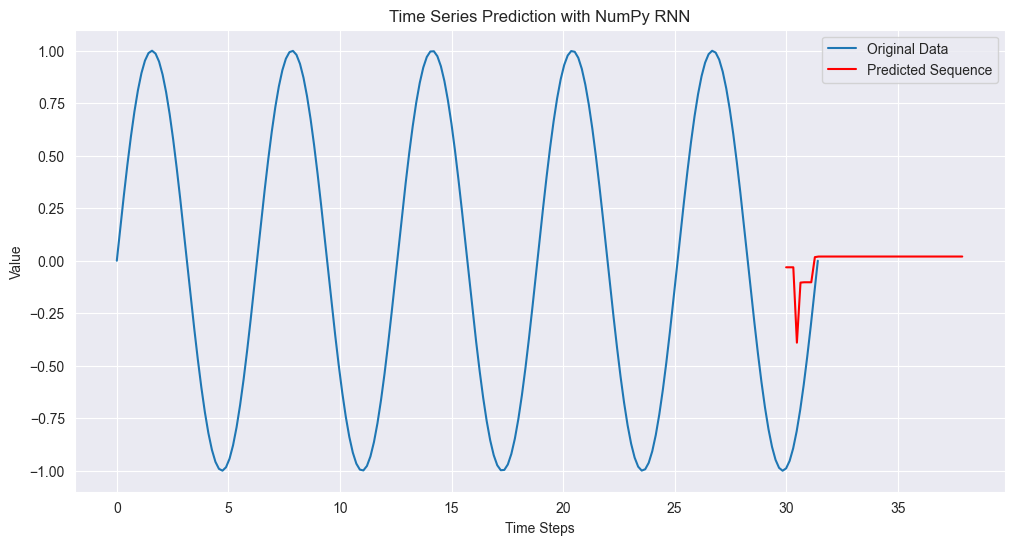

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Activation functions and their derivatives
def tanh(x):
    return np.tanh(x)

def dtanh(x):
    return 1 - np.tanh(x)**2

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def dsigmoid(x):
    return x * (1 - x)

# 2. RNN Class Implementation
class RNN:
    def __init__(self, input_dim, hidden_dim, output_dim):
        # Initialize dimensions
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim

        # Initialize weights and biases with random values from a uniform distribution
        self.Wxh = np.random.uniform(-0.1, 0.1, (hidden_dim, input_dim)) # Input to hidden
        self.Whh = np.random.uniform(-0.1, 0.1, (hidden_dim, hidden_dim)) # Hidden to hidden (recurrent)
        self.Why = np.random.uniform(-0.1, 0.1, (output_dim, hidden_dim)) # Hidden to output
        self.bh = np.zeros((hidden_dim, 1)) # Hidden bias
        self.by = np.zeros((output_dim, 1)) # Output bias

        # Initialize gradients for backpropagation
        self.dWxh, self.dWhh, self.dWhy = np.zeros_like(self.Wxh), np.zeros_like(self.Whh), np.zeros_like(self.Why)
        self.dbh, self.dby = np.zeros_like(self.bh), np.zeros_like(self.by)

    def forward(self, inputs):
        # Store hidden states and outputs for backpropagation
        self.h_states = {}
        self.y_outputs = {}
        self.h_states[-1] = np.zeros((self.hidden_dim, 1))

        for t in range(len(inputs)):
            # Convert input into the correct shape
            x_t = inputs[t].reshape(self.input_dim, 1)

            # Update hidden state
            self.h_states[t] = tanh(np.dot(self.Wxh, x_t) + np.dot(self.Whh, self.h_states[t-1]) + self.bh)

            # Calculate output
            self.y_outputs[t] = np.dot(self.Why, self.h_states[t]) + self.by

        return self.y_outputs

    def backward(self, inputs, targets, learning_rate):
        # Reset gradients
        self.dWxh, self.dWhh, self.dWhy = np.zeros_like(self.Wxh), np.zeros_like(self.Whh), np.zeros_like(self.Why)
        self.dbh, self.dby = np.zeros_like(self.bh), np.zeros_like(self.by)
        dh_next = np.zeros_like(self.h_states[0])

        for t in reversed(range(len(inputs))):
            x_t = inputs[t].reshape(self.input_dim, 1)

            # Output error
            dy = self.y_outputs[t] - targets[t].reshape(self.output_dim, 1)

            # Backpropagate to output weights and bias
            self.dWhy += np.dot(dy, self.h_states[t].T)
            self.dby += dy

            # Backpropagate to hidden state
            dh = np.dot(self.Why.T, dy) + dh_next

            # Backpropagate through tanh activation
            dh_raw = dtanh(self.h_states[t]) * dh

            # Backpropagate to input and recurrent weights/bias
            self.dWxh += np.dot(dh_raw, x_t.T)
            self.dWhh += np.dot(dh_raw, self.h_states[t-1].T)
            self.dbh += dh_raw

            # Set next hidden state gradient for Backpropagation Through Time (BPTT)
            dh_next = np.dot(self.Whh.T, dh_raw)

        # Clip gradients to prevent exploding gradients
        for grad in [self.dWxh, self.dWhh, self.dWhy, self.dbh, self.dby]:
            np.clip(grad, -1, 1, out=grad)

        # Update weights
        self.Wxh -= learning_rate * self.dWxh
        self.Whh -= learning_rate * self.dWhh
        self.Why -= learning_rate * self.dWhy
        self.bh -= learning_rate * self.dbh
        self.by -= learning_rate * self.dby

    def train(self, inputs, targets, epochs, learning_rate):
        for epoch in range(epochs):
            # Forward pass
            y_preds = self.forward(inputs)

            # Calculate loss (Mean Squared Error)
            loss = np.mean([(y_preds[t] - targets[t].reshape(self.output_dim, 1))**2 for t in range(len(inputs))])

            # Backward pass
            self.backward(inputs, targets, learning_rate)

            if epoch % 100 == 0:
                print(f'Epoch: {epoch}, Loss: {loss:.6f}')
        return y_preds

    def predict(self, start_sequence):
        # Reset hidden state for new sequence
        self.h_states = {-1: np.zeros((self.hidden_dim, 1))}

        # Process the start sequence to set the final hidden state
        for t in range(len(start_sequence)):
            x_t = start_sequence[t].reshape(self.input_dim, 1)
            self.h_states[t] = tanh(np.dot(self.Wxh, x_t) + np.dot(self.Whh, self.h_states[t-1]) + self.bh)

        # Make a prediction for the next step
        last_hidden_state = self.h_states[len(start_sequence) - 1]
        next_output = np.dot(self.Why, last_hidden_state) + self.by

        return next_output

# 3. Create a synthetic time series dataset
def create_sine_wave_data(sequence_length=50):
    t = np.linspace(0, 10 * np.pi, 200)
    data = np.sin(t)

    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])

    return np.array(X), np.array(y)

# 4. Prepare and train the model
if __name__ == '__main__':
    # Generate and preprocess data
    X_data, y_data = create_sine_wave_data(sequence_length=10)

    # Reshape for RNN input (samples, timesteps, features)
    X_train = np.array([X_data[i] for i in range(len(X_data))])
    y_train = np.array([y_data[i] for i in range(len(y_data))])

    # Model parameters
    input_size = 1
    hidden_size = 10
    output_size = 1

    # Initialize and train the RNN
    rnn = RNN(input_dim=input_size, hidden_dim=hidden_size, output_dim=output_size)

    # The training loop requires input sequences and corresponding target values.
    # The example needs to be restructured to feed individual sequences.
    print("Starting training...")
    epochs = 2000
    learning_rate = 0.001

    for epoch in range(epochs):
        epoch_loss = 0
        for i in range(len(X_train)):
            inputs = X_train[i].reshape(-1, 1) # reshape (timesteps, 1)
            targets = y_train[i].reshape(1, 1)  # reshape (1, 1)

            # Forward pass
            y_preds_dict = rnn.forward(inputs)
            y_pred = y_preds_dict[len(inputs)-1] # Get final prediction

            # Backward pass
            y_preds_full = np.array(list(y_preds_dict.values())).flatten()
            targets_full = np.array([y_train[i] for _ in range(len(inputs))])

            # Recompute loss on the full sequence for printing
            loss = np.mean((y_preds_full - targets_full)**2)
            epoch_loss += loss

            # The backward function is specific to a sequence
            rnn.backward(inputs, np.array([y_train[i] for _ in range(len(inputs))]).flatten(), learning_rate)

        if epoch % 100 == 0:
            print(f'Epoch: {epoch}, Avg Loss: {epoch_loss/len(X_train):.6f}')

    # 5. Make predictions with the trained model
    print("\nTraining complete. Making predictions...")

    # Use the last 10 points of the training data to start the prediction
    start_sequence = X_train[-1]

    # Generate a forecast for 50 steps
    predicted_sequence = []
    current_input = start_sequence
    for _ in range(50):
        # Get the prediction for the next step
        next_step_pred = rnn.predict(current_input).item()
        predicted_sequence.append(next_step_pred)

        # Update the sequence for the next prediction
        current_input = np.append(current_input[1:], next_step_pred)

    # 6. Plot the results with corrected indices
plt.figure(figsize=(12, 6))

# Plot the original data
# The original data has a length equal to the number of samples plus the sequence length
# minus one. Let's create the correct x-axis for it.
t = np.linspace(0, 10 * np.pi, 200) # Re-generate the full time series
plt.plot(t, np.sin(t), label='Original Data')

# Plot the predicted sequence
# Start plotting the predicted sequence after the training data ends.
# The original data ends at index 199. The start of the predicted sequence is at index 200.
prediction_start_t = t[-len(start_sequence)]
predicted_t = np.linspace(prediction_start_t, prediction_start_t + 50 * (t[1]-t[0]), 50)
plt.plot(predicted_t, predicted_sequence, 'r-', label='Predicted Sequence')

plt.title("Time Series Prediction with NumPy RNN")
plt.xlabel("Time Steps")
plt.ylabel("Value")
plt.legend()
plt.show()



#### Your basic NumPy RNN is likely failing to accurately predict the sine wave due to the vanishing gradient problem, a fundamental limitation of simple RNN architectures. The simple RNN struggles to learn long-term dependencies, which is critical for a periodic pattern like a sine wave

In [ ]:
# Create a new LSTM cell class within your existing code
class LSTMCell:
    def __init__(self, input_dim, hidden_dim):
        # Weight and bias initialization (can be improved)
        self.Wf = np.random.uniform(-0.1, 0.1, (hidden_dim, input_dim + hidden_dim))
        self.bf = np.zeros((hidden_dim, 1))
        self.Wi = np.random.uniform(-0.1, 0.1, (hidden_dim, input_dim + hidden_dim))
        self.bi = np.zeros((hidden_dim, 1))
        self.Wc = np.random.uniform(-0.1, 0.1, (hidden_dim, input_dim + hidden_dim))
        self.bc = np.zeros((hidden_dim, 1))
        self.Wo = np.random.uniform(-0.1, 0.1, (hidden_dim, input_dim + hidden_dim))
        self.bo = np.zeros((hidden_dim, 1))

    # You would then need to implement forward and backward passes for this cell
    # and integrate it into your main training loop.
